In [1]:
# ! pip install -U torchvision
# !pip install -U torch

In [2]:
# 1: Bib
import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import resnet18

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


In [3]:
# 2: CSV laden

df = pd.read_csv("dataset/labels.csv")

df.head()

# check:
print(df.shape)

(347085, 4)


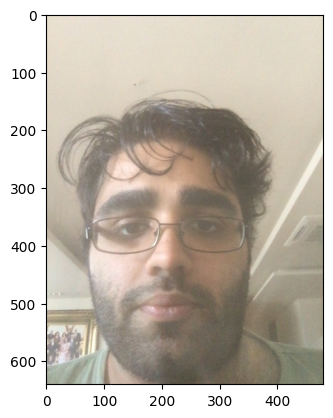

160.0 284.0


In [4]:
# 3: check a image

row = df.iloc[0]

img = Image.open(row["image_name"])

plt.imshow(img)
plt.show()

print(row["x"], row["y"])

In [6]:
row = df.iloc[100000]

img = Image.open(row["image_name"])

# plt.imshow(img)
# plt.show()

print(row["x"], row["y"])

304.468243182 180.574068725


In [7]:
# 4: Dataset Class: transfer CSV in PyTorch.

class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None):

        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_name"]
        ).convert("RGB")

        target = torch.tensor(
            [row["x"], row["y"]],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)
        

        return image, target
        return 

In [30]:
# 5: DataLoader

# Transformationen:

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


# Dataset:

train_dataset = GazeDataset(
    "./splits/subject_train.csv",
    transform
)

test_dataset = GazeDataset(
    "./splits/subject_test.csv",
    transform
)

print(len(train_dataset))
print(len(test_dataset))


# Loader:

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4
)


284310
62775


In [29]:
# debug:

train_df = pd.read_csv(
    "./splits/subject_train.csv"
)

train_df = train_df.sample(
    n=10000,
    random_state=42
)

train_df.to_csv(
    "./splits/debug_train.csv",
    index=False
)

train_dataset_deb = GazeDataset(
    "./splits/debug_train.csv",
    transform
)


test_df = pd.read_csv(
    "./splits/subject_test.csv"
)

test_df = test_df.sample(
    n=2000,
    random_state=42
)

test_df.to_csv(
    "./splits/debug_test.csv",
    index=False
)

test_dataset_deb = GazeDataset(
    "./splits/debug_test.csv",
    transform
)



# Loader:

train_loader = DataLoader(
    train_dataset_deb,
    batch_size=64,
    shuffle=True,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset_deb,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

print("Train samples:", len(train_dataset_deb))
print("Test samples :", len(test_dataset_deb))


Train samples: 10000
Test samples : 2000


In [11]:
# 6: ResNet18 (Pretrainiertes Modell):

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# Load:

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# last layer Original: 512 → 1000, but we need: 512 → 2 (for x, y)

model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        128
    ),
    nn.ReLU(),

    nn.Dropout(0.2),

    nn.Linear(
        128,
        2
    )
)

In [18]:
# 7: GPU

# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

model.to(device)

2.12.1+cu130
False
13.0
cpu


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [13]:
# 8: Loss and Optimizer

# for regression:
# criterion = nn.MSELoss()

criterion = nn.SmoothL1Loss()

# Optimizer:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


In [31]:
# check the size of dataset:

print(len(train_dataset))
print(len(test_dataset))

print(len(train_dataset_deb))
print(len(test_dataset_deb))

284310
62775
10000
2000


In [32]:
# check before training:

# test 1:
images, targets = next(iter(train_loader))
print("test 1:")
print(images.shape)
print(targets.shape)


# test 2
import time

start = time.time()

images, targets = next(iter(train_loader))

end = time.time()
print("test 2:")
print("Loading time:", end-start)

# test 3:
images, targets = next(iter(train_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)
print("test 3:")
print(preds.shape)

test 1:
torch.Size([64, 3, 224, 224])
torch.Size([64, 2])
test 2:
Loading time: 1.5359368324279785
test 3:
torch.Size([64, 2])


* test 1:


torch.Size([64, 3, 224, 224])
torch.Size([64, 2])

* test 2:

Loading time: 0.39045047760009766

* test 3:

torch.Size([64, 2])

In [33]:
# test: time 

import time

images, targets = next(iter(train_loader))

images = images.to(device)
targets = targets.to(device)

start = time.time()

preds = model(images)

loss = criterion(preds, targets)

loss.backward()

optimizer.step()

end = time.time()

print("Train step:", end-start)

Train step: 6.540175199508667


In [34]:
# 9: Training

from tqdm import tqdm

epochs = 1
# epochs = 2
# epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}"
    )

    for images, targets in loop:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss/len(train_loader):.4f}"
    )

Epoch 1:   5%|██████                                                                                                          | 239/4443 [35:21<10:21:52,  8.88s/it, loss=160]


KeyboardInterrupt: 

In [22]:
# save the model:

torch.save(
    model.state_dict(),
    "gaze_model.pth"
)

In [23]:
# Inference 

model.load_state_dict(
    torch.load(
        "gaze_model.pth"
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [24]:

predictions = []
targets_all = []

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)

        preds = model(images)

        predictions.append(
            preds.cpu()
        )

        targets_all.append(
            targets
        )


predictions = torch.cat(
    predictions
)

targets_all = torch.cat(
    targets_all
)

In [27]:
# 10: Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

screen_w = 984.0

mae = mean_absolute_error(
    targets_all.numpy(),
    predictions.numpy()
)


rmse = np.sqrt(
    mean_squared_error(
        targets_all.numpy(),
        predictions.numpy()
    )
)

print("MAE :", mae)
print("RMSE:", rmse)


#print(f"\nDiagonal-Error %: {100*np.round(mae / np.sqrt(2*screen_w**2), 3)} %")
print(f"\n\nDiagonal-Error %: {100*np.round(rmse / np.sqrt(2*screen_w**2), 3)} %")


MAE : 255.96157836914062
RMSE: 332.41441567717845


Diagonal-Error %: 23.9 %


In [ ]:
# 11: save Modell 

torch.save(
    model.state_dict(),
    "gaze_resnet18.pth"
)

In [ ]:
# 12: load

model.load_state_dict(
    torch.load(
        "gaze_resnet18.pth"
    )
)

In [ ]:
resnet = models.resnet18(weights="IMAGENET1K_V1")


In [ ]:
import time

images, targets = next(iter(train_loader))

images = images.to(device)
targets = targets.to(device)

start = time.time()

preds = model(images)

loss = criterion(preds, targets)

loss.backward()

optimizer.step()

end = time.time()

print("Train step:", end-start)

In [ ]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

# zusätzlich:

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

In [ ]:
model.eval()

image, target = test_dataset[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0).to(device)
    )

print("True :", target)
print("Pred :", pred)